# PCA on returns

Same pipeline as `simple_PCA`, but on **daily returns** (simple/percent returns, *not* log) instead of raw prices. Returns are the stationary increments, so PC1 stops being 'the trend' and becomes genuine co-movement structure.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stonks import get_prices, to_returns, load_universe

%matplotlib inline


## Parameters

Same as before: last 2 years, most-liquid `TOP_N` stocks, adjusted close.


In [2]:
PERIOD = "2y"
INTERVAL = "1d"
TOP_N = 50
FIELD = "close"   # adjusted close -> total returns


## Fetch prices


In [3]:
prices = get_prices(top_n=TOP_N, period=PERIOD, interval=INTERVAL, field=FIELD)
prices


Date,2024-08-13,2024-08-14,2024-08-15,2024-08-16,2024-08-19,2024-08-20,2024-08-21,2024-08-22,2024-08-23,2024-08-26,...,2026-07-31,2026-08-03,2026-08-04,2026-08-05,2026-08-06,2026-08-07,2026-08-10,2026-08-11,2026-08-12,2026-08-13
ticker,,,,,,,,,,,,,,,,,,,,,
NVDA,115.948898,117.885704,122.657829,124.375008,129.786087,127.040604,128.288574,123.536377,129.157135,126.251907,...,200.750000,206.639999,211.940002,219.220001,218.990005,223.960007,217.550003,217.500000,224.089996,225.789993
TSLA,207.830002,201.380005,214.139999,216.119995,222.720001,221.100006,223.270004,210.660004,220.320007,213.210007,...,311.209991,322.079987,327.350006,321.549988,319.529999,328.579987,330.880005,332.809998,327.510010,338.174988
SPCX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,108.370003,114.529999,125.330002,108.269997,114.919998,133.110001,138.740005,133.289993,146.149994,142.239899
AAPL,219.434372,219.880646,222.855759,224.174713,224.016068,224.630920,224.521805,222.667358,224.958191,225.295364,...,308.643829,303.158569,309.113403,310.732025,312.140808,313.059998,308.260010,304.910004,302.250000,303.440002
MU,96.831024,99.782455,106.281570,107.315079,107.951088,107.315079,107.652954,103.608391,102.207207,98.291832,...,823.030029,829.500000,892.669983,893.190002,881.469971,877.570007,861.000000,868.520020,911.289978,966.780029
MSFT,407.604218,410.410126,415.262695,412.737732,415.755859,418.981079,418.330109,409.857727,411.080811,407.825958,...,464.720001,487.649994,492.809998,487.459991,499.859985,499.989990,506.059998,503.809998,492.429993,494.989990
AMZN,170.229996,170.100006,177.589996,177.059998,178.220001,178.880005,180.110001,176.130005,177.039993,175.500000,...,271.579987,284.019989,277.420013,272.649994,272.260010,274.480011,278.089996,272.269989,267.279999,265.915009
META,525.015686,523.247498,533.747070,523.903076,525.750732,523.217651,531.591492,528.383057,524.479309,517.645203,...,556.710022,590.239990,587.940002,588.770020,589.900024,592.099976,594.919983,599.119995,578.849976,589.474976
AMD,141.130005,140.750000,147.360001,148.559998,155.279999,156.399994,157.809998,151.699997,154.979996,149.990005,...,476.149994,484.640015,518.580017,482.049988,489.279999,483.359985,469.559998,474.320007,482.929993,491.230011


## Returns (daily, simple)

`to_returns` gives $R_t = P_t/P_{t-1} - 1$ (no log). This is the N×(T−1) matrix of **percent moves** — the stationary increments we actually want to model. (The leading column with no prior day is dropped.)


In [4]:
returns = to_returns(prices)
print("returns shape:", returns.shape, "| prices shape:", prices.shape)
returns


returns shape: (50, 501) | prices shape: (50, 502)


Date,2024-08-14,2024-08-15,2024-08-16,2024-08-19,2024-08-20,2024-08-21,2024-08-22,2024-08-23,2024-08-26,2024-08-27,...,2026-07-31,2026-08-03,2026-08-04,2026-08-05,2026-08-06,2026-08-07,2026-08-10,2026-08-11,2026-08-12,2026-08-13
ticker,,,,,,,,,,,,,,,,,,,,,
NVDA,0.016704,0.040481,0.014000,0.043506,-0.021154,0.009823,-0.037043,0.045499,-0.022494,0.014550,...,0.029276,0.029340,0.025648,0.034349,-0.001049,0.022695,-0.028621,-0.000230,0.030299,0.007586
TSLA,-0.031035,0.063363,0.009246,0.030539,-0.007274,0.009815,-0.056479,0.045856,-0.032271,-0.018761,...,0.007641,0.034928,0.016362,-0.017718,-0.006282,0.028323,0.007000,0.005833,-0.015925,0.032564
SPCX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.034135,0.056842,0.094298,-0.136121,0.061421,0.158284,0.042296,-0.039282,0.096481,-0.026754
AAPL,0.002034,0.013531,0.005918,-0.000708,0.002745,-0.000486,-0.008260,0.010288,0.001499,0.003741,...,-0.073539,-0.017772,0.019643,0.005236,0.004534,0.002945,-0.015332,-0.010867,-0.008724,0.003937
MU,0.030480,0.065133,0.009724,0.005927,-0.005892,0.003148,-0.037570,-0.013524,-0.038308,-0.010616,...,-0.059029,0.007861,0.076154,0.000583,-0.013122,-0.004424,-0.018882,0.008734,0.049245,0.060892
MSFT,0.006884,0.011824,-0.006080,0.007312,0.007757,-0.001554,-0.020253,0.002984,-0.007918,0.000847,...,0.030193,0.049342,0.010581,-0.010856,0.025438,0.000260,0.012140,-0.004446,-0.022588,0.005199
AMZN,-0.000764,0.044033,-0.002984,0.006551,0.003703,0.006876,-0.022098,0.005167,-0.008699,-0.013561,...,0.153206,0.045806,-0.023238,-0.017194,-0.001430,0.008154,0.013152,-0.020929,-0.018327,-0.005107
META,-0.003368,0.020066,-0.018443,0.003527,-0.004818,0.016005,-0.006036,-0.007388,-0.013030,-0.003877,...,0.032800,0.060229,-0.003897,0.001412,0.001919,0.003729,0.004763,0.007060,-0.033833,0.018355
AMD,-0.002693,0.046963,0.008143,0.045234,0.007213,0.009015,-0.038717,0.021622,-0.032198,0.003400,...,-0.019036,0.017831,0.070031,-0.070442,0.014998,-0.012099,-0.028550,0.010137,0.018152,0.017187


### What do daily returns look like?

A quick peek at the distribution — this is what we'd eventually put a likelihood on (Gaussian? heavier tails?).


Text(0, 0.5, 'count')

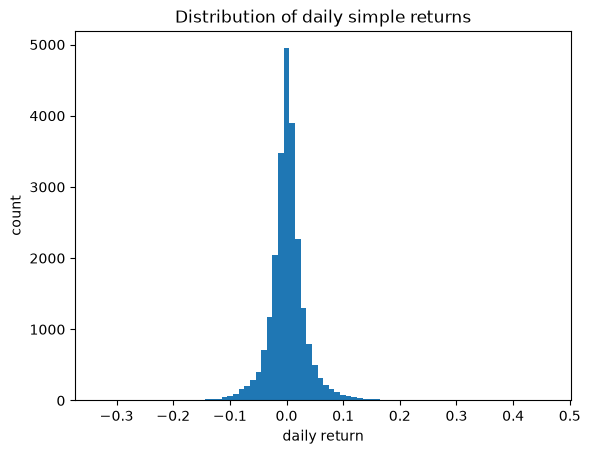

In [5]:
vals = returns.to_numpy().ravel()
vals = vals[~np.isnan(vals)]
plt.hist(vals, bins=80)
plt.title("Distribution of daily simple returns")
plt.xlabel("daily return"); plt.ylabel("count")


## Clean & centre

Drop stocks with any missing days, then centre each stock's returns by its own mean return.


In [6]:
returns_clean = returns.dropna()
X = returns_clean.to_numpy(dtype=float)
tickers = list(returns_clean.index)
scale = np.sqrt(len(tickers))   # sqrt(N): unit-variance loadings (~ N(0,1) under noise)

X_centered = X - X.mean(axis=1, keepdims=True)
print("X.shape:", X.shape, "| N stocks:", len(tickers))


X.shape: (45, 501) | N stocks: 45


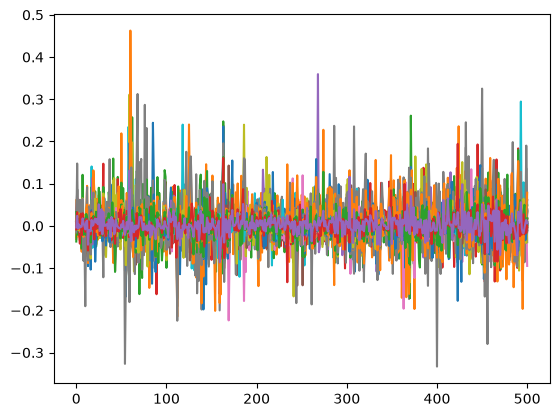

In [17]:
plt.plot(X.T);

## Covariance of returns

Stock×stock covariance of centred returns, normalised by **T** (the time axis). Unlike the price covariance, this measures co-*movement* (percent moves), not level.


Text(0, 0.5, 'stock')

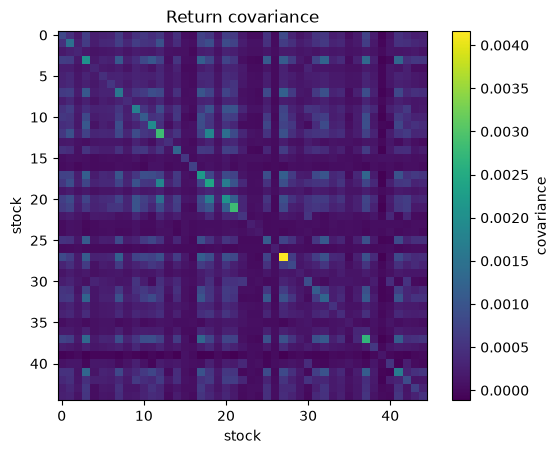

In [7]:
cov = (X_centered @ X_centered.T) / X_centered.shape[1]

plt.imshow(cov)
plt.colorbar(label="covariance")
plt.title("Return covariance"); plt.xlabel("stock"); plt.ylabel("stock")


## PCA via SVD

Compare the variance fractions to `simple_PCA` (where PC1 was ~98%). On returns the spectrum is much flatter — PC1 is now a real co-movement factor, not a trend.


In [8]:
U, S, Vt = np.linalg.svd(cov)
var = S ** 2 / (S ** 2).sum()
print("variance explained: PC1=%.1f%%  PC2=%.1f%%  PC3=%.1f%%" % (var[0]*100, var[1]*100, var[2]*100))


variance explained: PC1=84.3%  PC2=6.9%  PC3=2.6%


## Stocks in PCA space

Same `sqrt(N)` Gaussian scaling as before. `(U[i,0], U[i,1])` is stock *i*'s coordinate on PC1/PC2.


In [9]:
uni = load_universe()
NAMES = dict(zip(uni["ticker"], uni["name"]))

def label(t: str) -> str:
    return f"{t} ({NAMES.get(t, '')[:22]})"


Text(0.5, 1.0, 'Stocks in PCA space (return covariance, top 2 components)')

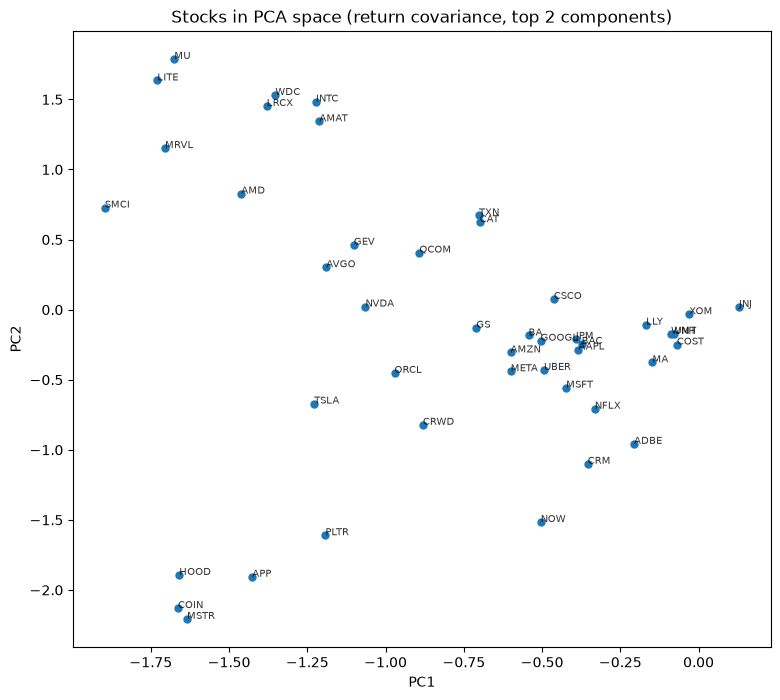

In [10]:
coords = U[:, :2] * scale
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(coords[:, 0], coords[:, 1], s=25)
for i, t in enumerate(tickers):
    ax.annotate(t, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.8)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Stocks in PCA space (return covariance, top 2 components)")


## Which stocks are similar?

Nearest neighbours in the top-`k` PCA space — now in *co-movement*, not drift.


In [11]:
k = 5
Z = U[:, :k] * scale
D = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
np.fill_diagonal(D, np.inf)

iu = np.triu_indices(len(tickers), k=1)
print("most similar pairs:")
for r in np.argsort(D[iu])[:10]:
    i, j = iu[0][r], iu[1][r]
    print(f"  d={D[i, j]:.3f}  {label(tickers[i]):30s} ~ {label(tickers[j])}")


most similar pairs:
  d=0.085  JPM (JP Morgan Chase & Co. )   ~ BAC (Bank of America Corpor)
  d=0.126  WMT (Walmart Inc. - Common )   ~ COST (Costco Wholesale Corpo)
  d=0.193  XOM (ExxonMobil Holdings Co)   ~ JNJ (Johnson & Johnson Comm)
  d=0.243  GOOGL (Alphabet Inc. - Class ) ~ BAC (Bank of America Corpor)
  d=0.260  WMT (Walmart Inc. - Common )   ~ XOM (ExxonMobil Holdings Co)
  d=0.296  GOOGL (Alphabet Inc. - Class ) ~ JPM (JP Morgan Chase & Co. )
  d=0.299  AMAT (Applied Materials, Inc)  ~ LRCX (Lam Research Corporati)
  d=0.300  CRM (Salesforce, Inc. Commo)   ~ ADBE (Adobe Inc. - Common St)
  d=0.318  AAPL (Apple Inc. - Common St)  ~ BA (Boeing Company (The) C)
  d=0.321  AAPL (Apple Inc. - Common St)  ~ MA (Mastercard Incorporate)


In [12]:
target = "AAPL"
i = tickers.index(target)
j = int(D[i].argmin())
print(f"{label(target)}'s nearest neighbour: {label(tickers[j])}  (d={D[i, j]:.3f})")


AAPL (Apple Inc. - Common St)'s nearest neighbour: BA (Boeing Company (The) C)  (d=0.318)
